In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
# read the necessary data
rawdata = pd.read_csv('./data/clean/clean_data.csv')
# convert the date column to datetime format
# format="mixed" parses each value independently (the column mixes dd/mm/yyyy and
# dd/mm/yy, e.g. some days in Oct-Dec 2024 use a 2-digit year); inferring a single
# format for the whole column would silently coerce mismatched rows to NaT and drop
# them in the groupby below.
rawdata["DATE"] = pd.to_datetime(rawdata["DATE"], format="mixed", dayfirst=True, errors='coerce')
# turn all column into numeric, except the date  and heure columns
for col in rawdata.columns:
    if col not in ['DATE', 'HEURE']:
        rawdata[col] = pd.to_numeric(rawdata[col], errors='coerce')

# replace Heure values by categories
# 8h00 is the morning, 10h30 or 10h00 is midday, 14h00 or 15h30 is the afternoon.
def categorize_heure(heure):
    if pd.isna(heure):
        return np.nan
    else:
        heure = str(heure).strip()  # Remove any leading/trailing whitespace
        if heure in ['8h00', '8h30']:
            return 'morning'
        elif heure in ['10h00', '10h30']:
            return 'midday'
        elif heure in ['14h00', '15h00', '15h30']:
            return 'afternoon'
        else:
            return 'unknown'
rawdata['HEURE'] = rawdata['HEURE'].apply(categorize_heure)

# avergae the values of the same day
avgdata = rawdata.drop(columns=['HEURE']).groupby('DATE').mean().reset_index()

## Sand Filter

In [4]:
# select column that have SF in their name
SF_data = avgdata[['DATE'] + [col for col in avgdata.columns if 'SF' in col]]
SF_data.head()

,DATE,Ph_O_SF_A,Température_O_SF_A,Conductivité_O_SF_A,TDS_O_SF_A,Turbidité_O_SF_A,Ph_O_SF_B,Température_O_SF_B,Conductivité_O_SF_B,TDS_O_SF_B,Turbidité_O_SF_B
0,2024-01-01,8.12,17.233333,55.000000,33.00,0.016667,8.136667,17.233333,55.00,33.00,0.023333
1,2024-01-02,8.13,16.900000,55.000000,33.00,0.010000,8.130000,16.900000,55.00,33.00,0.013333
2,2024-01-03,8.17,17.466667,54.800000,32.88,0.010000,8.193333,17.333333,54.80,32.88,0.010000
3,2024-01-04,8.18,16.466667,55.066667,33.04,0.023333,8.160000,16.600000,55.05,33.03,0.015000
4,2024-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Descriptive Statistics

In [5]:
SF_data.describe()

,DATE,Ph_O_SF_A,Température_O_SF_A,Conductivité_O_SF_A,TDS_O_SF_A,Turbidité_O_SF_A,Ph_O_SF_B,Température_O_SF_B,Conductivité_O_SF_B,TDS_O_SF_B,Turbidité_O_SF_B
count,346,308.00000,307.000000,32.000000,32.000000,310.000000,309.000000,308.000000,32.000000,32.000000,310.000000
mean,2024-07-06 00:00:00,8.04471,19.963388,54.844792,32.881875,0.024285,8.043576,19.918642,54.850521,32.885312,0.022734
min,2024-01-01 00:00:00,7.86000,15.433333,53.233333,31.940000,0.000000,7.860000,15.433333,53.233333,31.940000,0.000000
25%,2024-03-29 06:00:00,8.00000,17.000000,54.891667,32.910000,0.000000,8.000000,17.000000,54.891667,32.910000,0.000000
50%,2024-06-29 12:00:00,8.04000,19.700000,54.983333,32.990000,0.000000,8.040000,19.600000,54.983333,32.990000,0.000000
75%,2024-09-29 18:00:00,8.08000,22.800000,55.075000,33.045000,0.019167,8.080000,22.625000,55.133333,33.080000,0.013333
max,2025-01-31 00:00:00,8.30000,27.600000,55.300000,33.180000,0.476667,8.300000,27.500000,55.300000,33.180000,0.536667
std,NaN,0.06892,3.115140,0.475312,0.312342,0.055885,0.067849,3.101257,0.478638,0.314448,0.053894


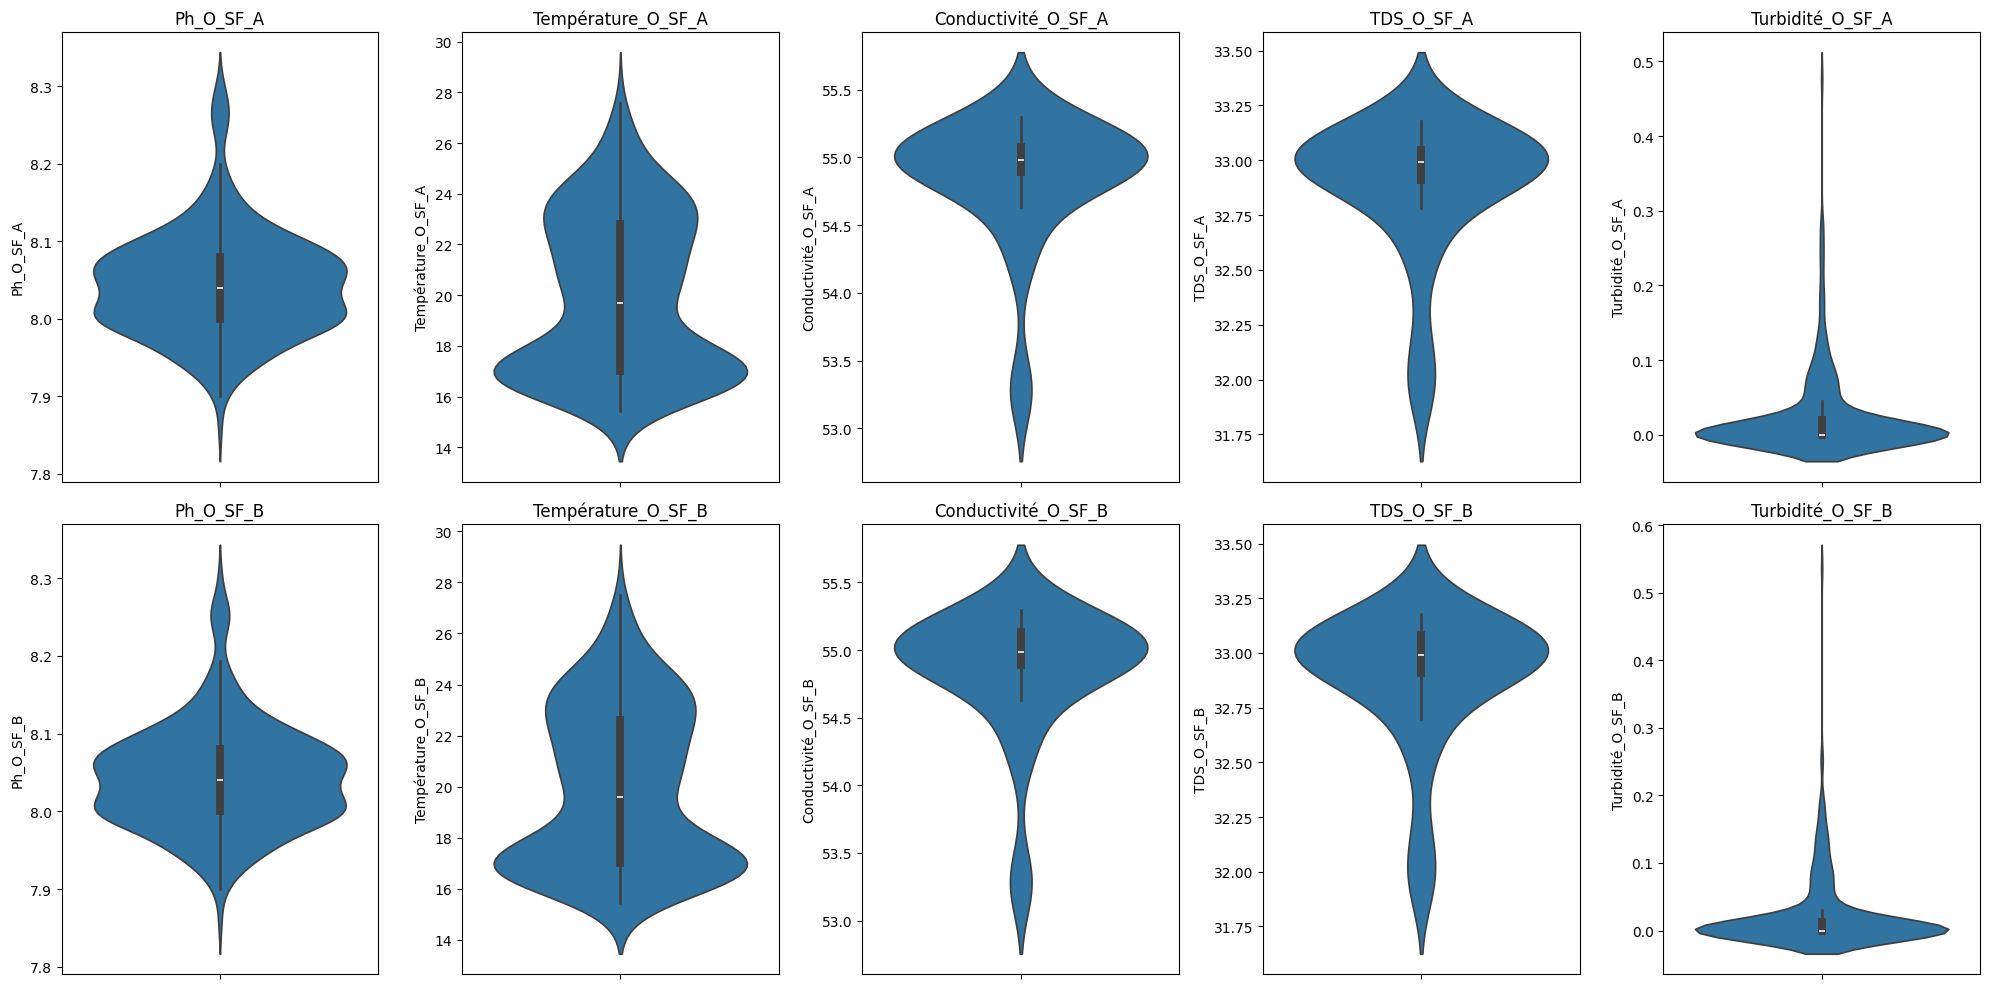

In [6]:
# boxplot of SF data
n_cols = 5
n_rows = -(-((len(SF_data.columns) - 1)) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()
for ax, col in zip(axes, SF_data.columns[1:]):
    sns.violinplot(y=SF_data[col], ax=ax)
    ax.set_title(col)
for ax in axes[len(SF_data.columns) - 1:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

#### Temporal Evolution of the data

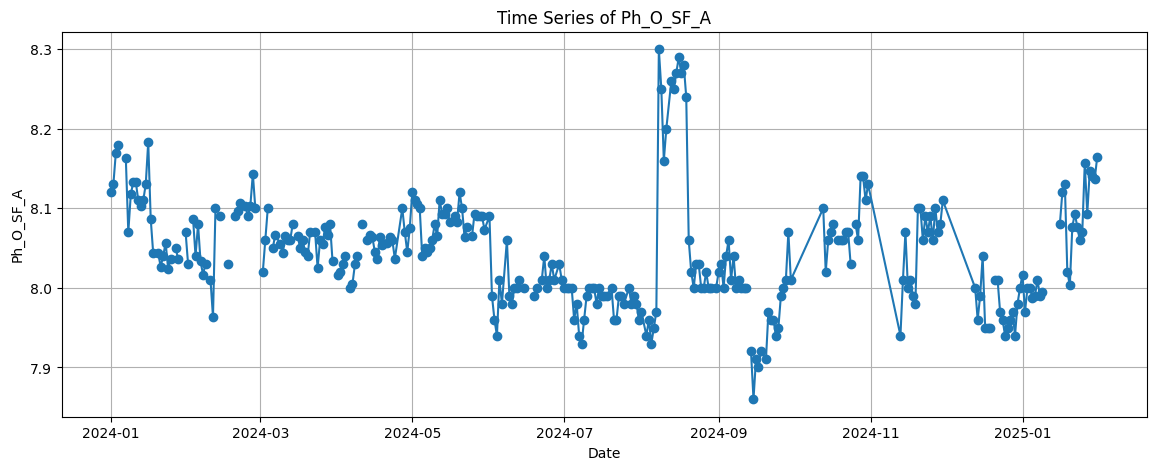

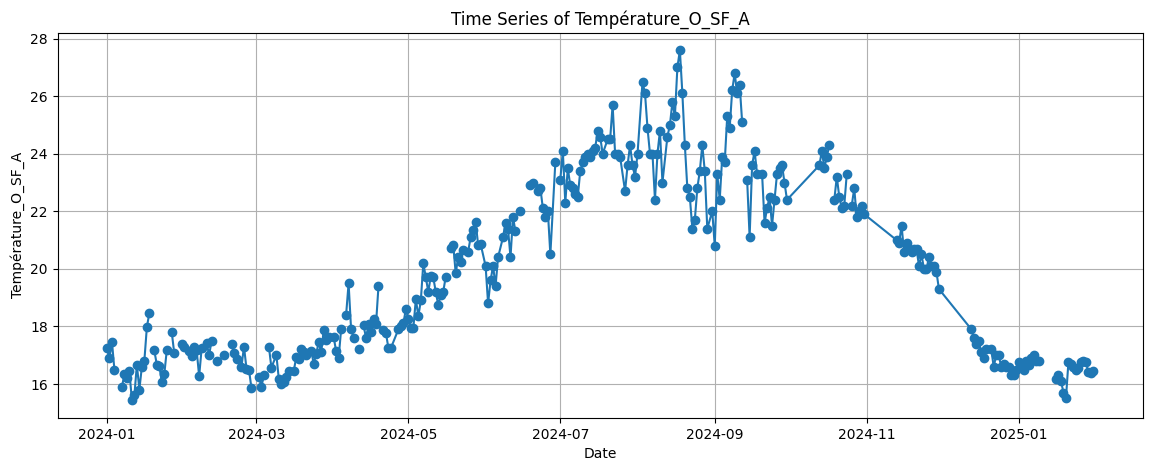

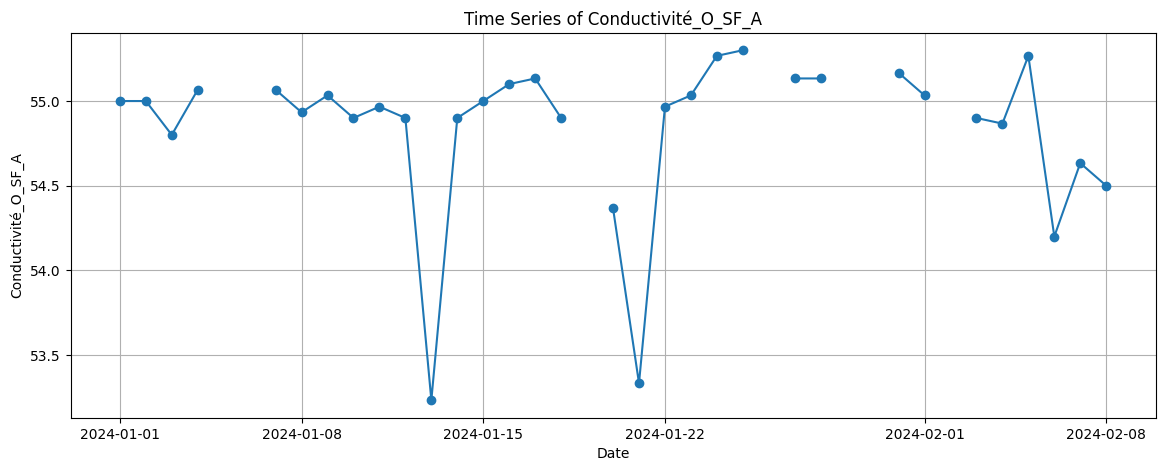

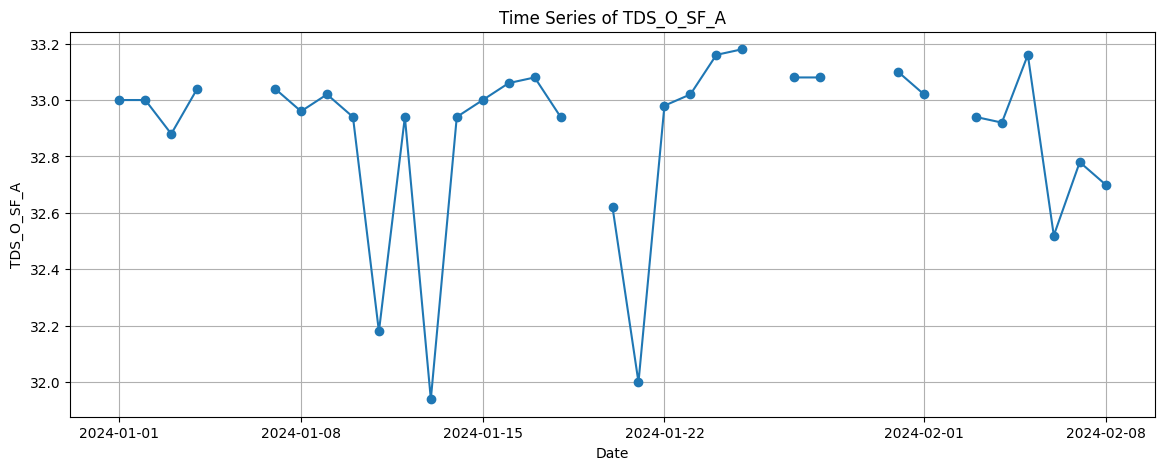

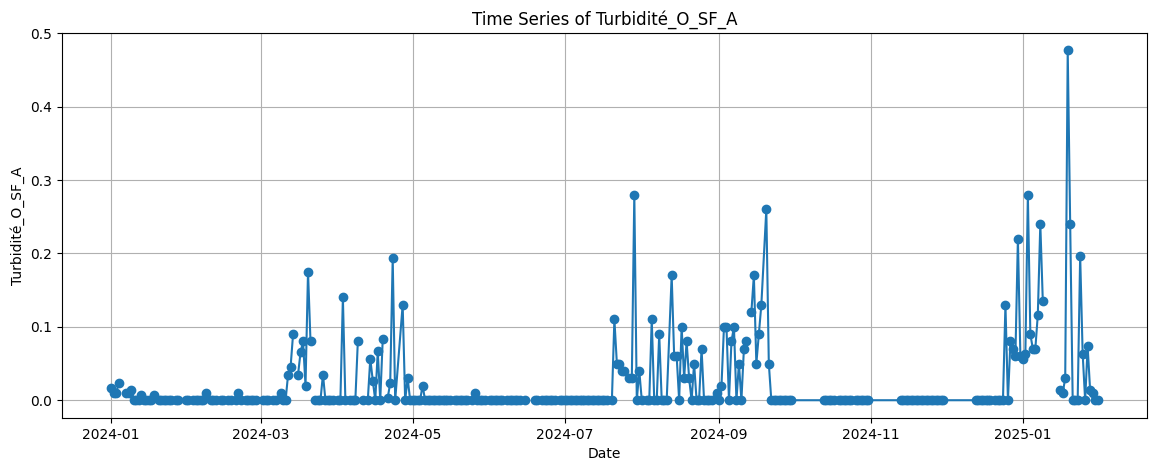

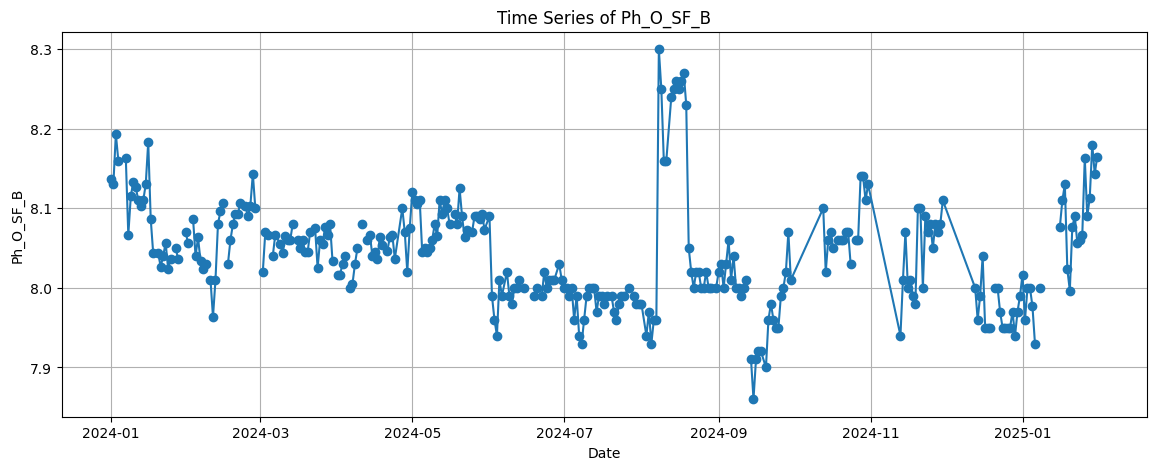

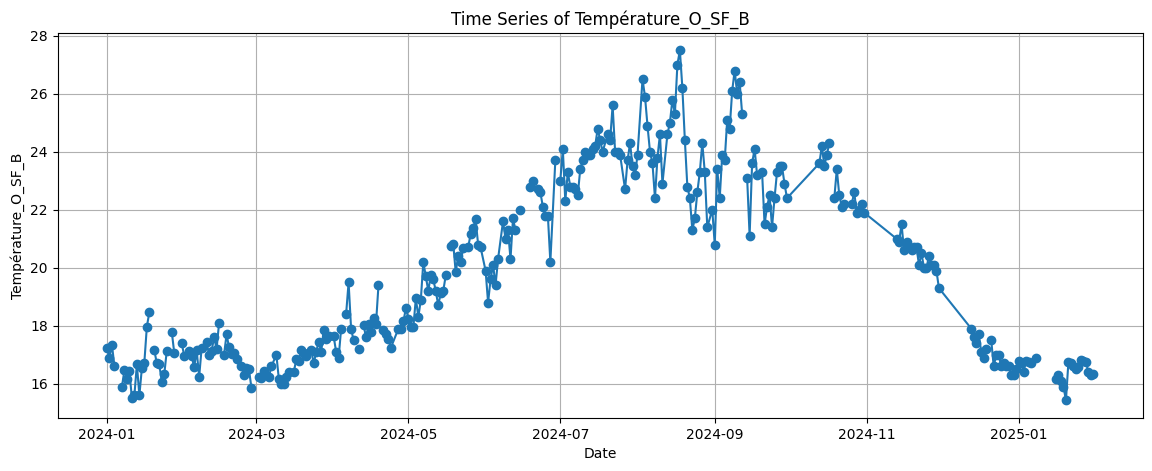

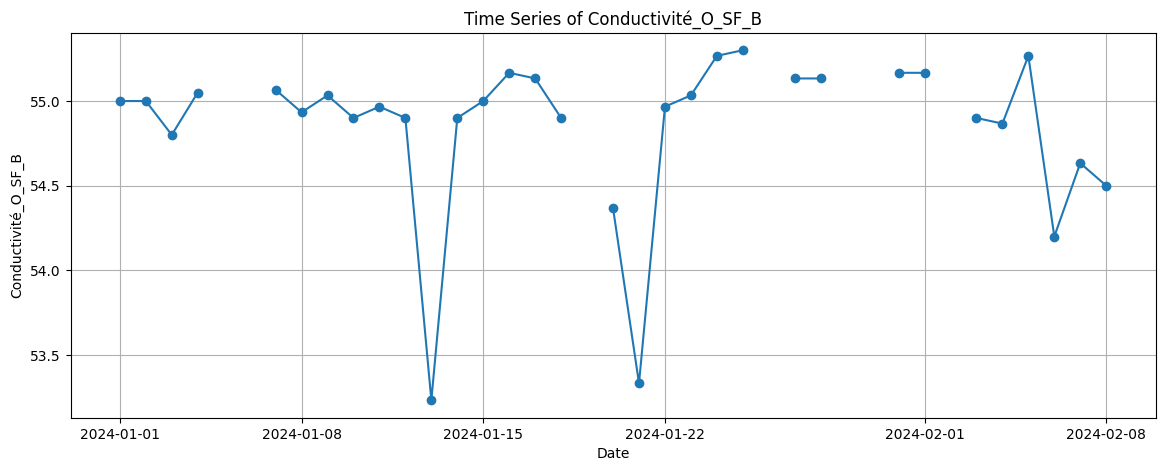

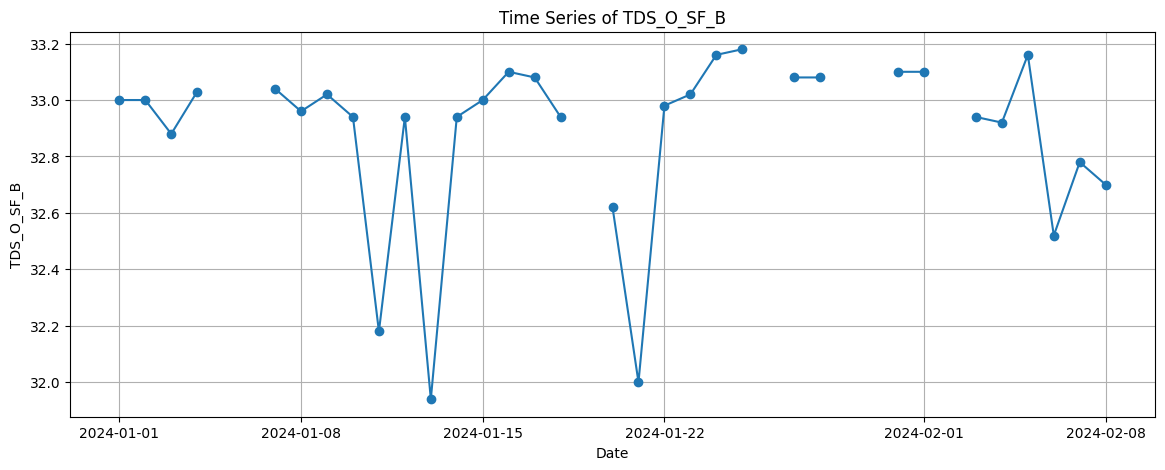

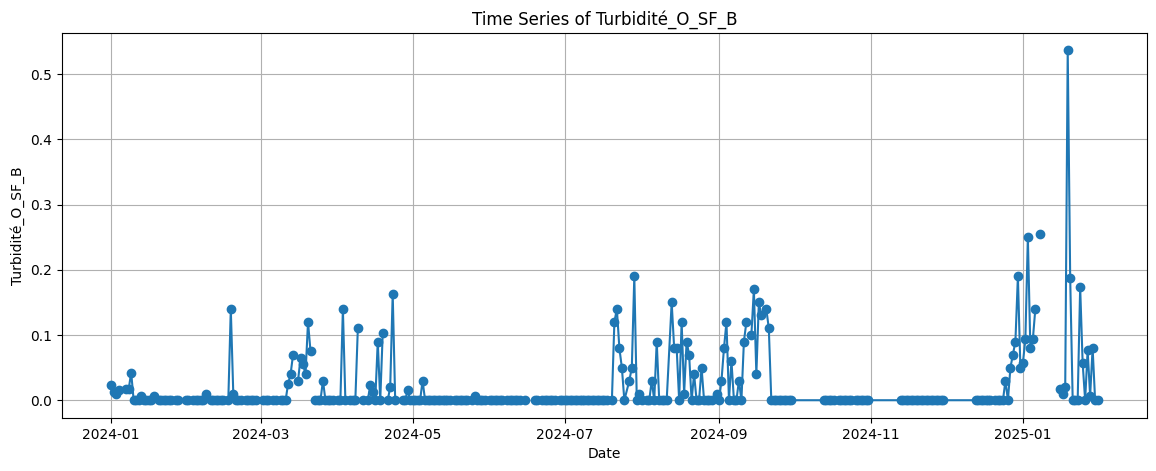

In [8]:
for col in SF_data.columns:
    if col != 'DATE':
        plt.figure(figsize=(14, 5))
        plt.plot(SF_data['DATE'], SF_data[col], marker='o')
        plt.title(f'Time Series of {col}')
        plt.xlabel('Date')
        plt.ylabel(col)
        plt.grid()
        plt.show()

#### Visualtion of the relationship between variables

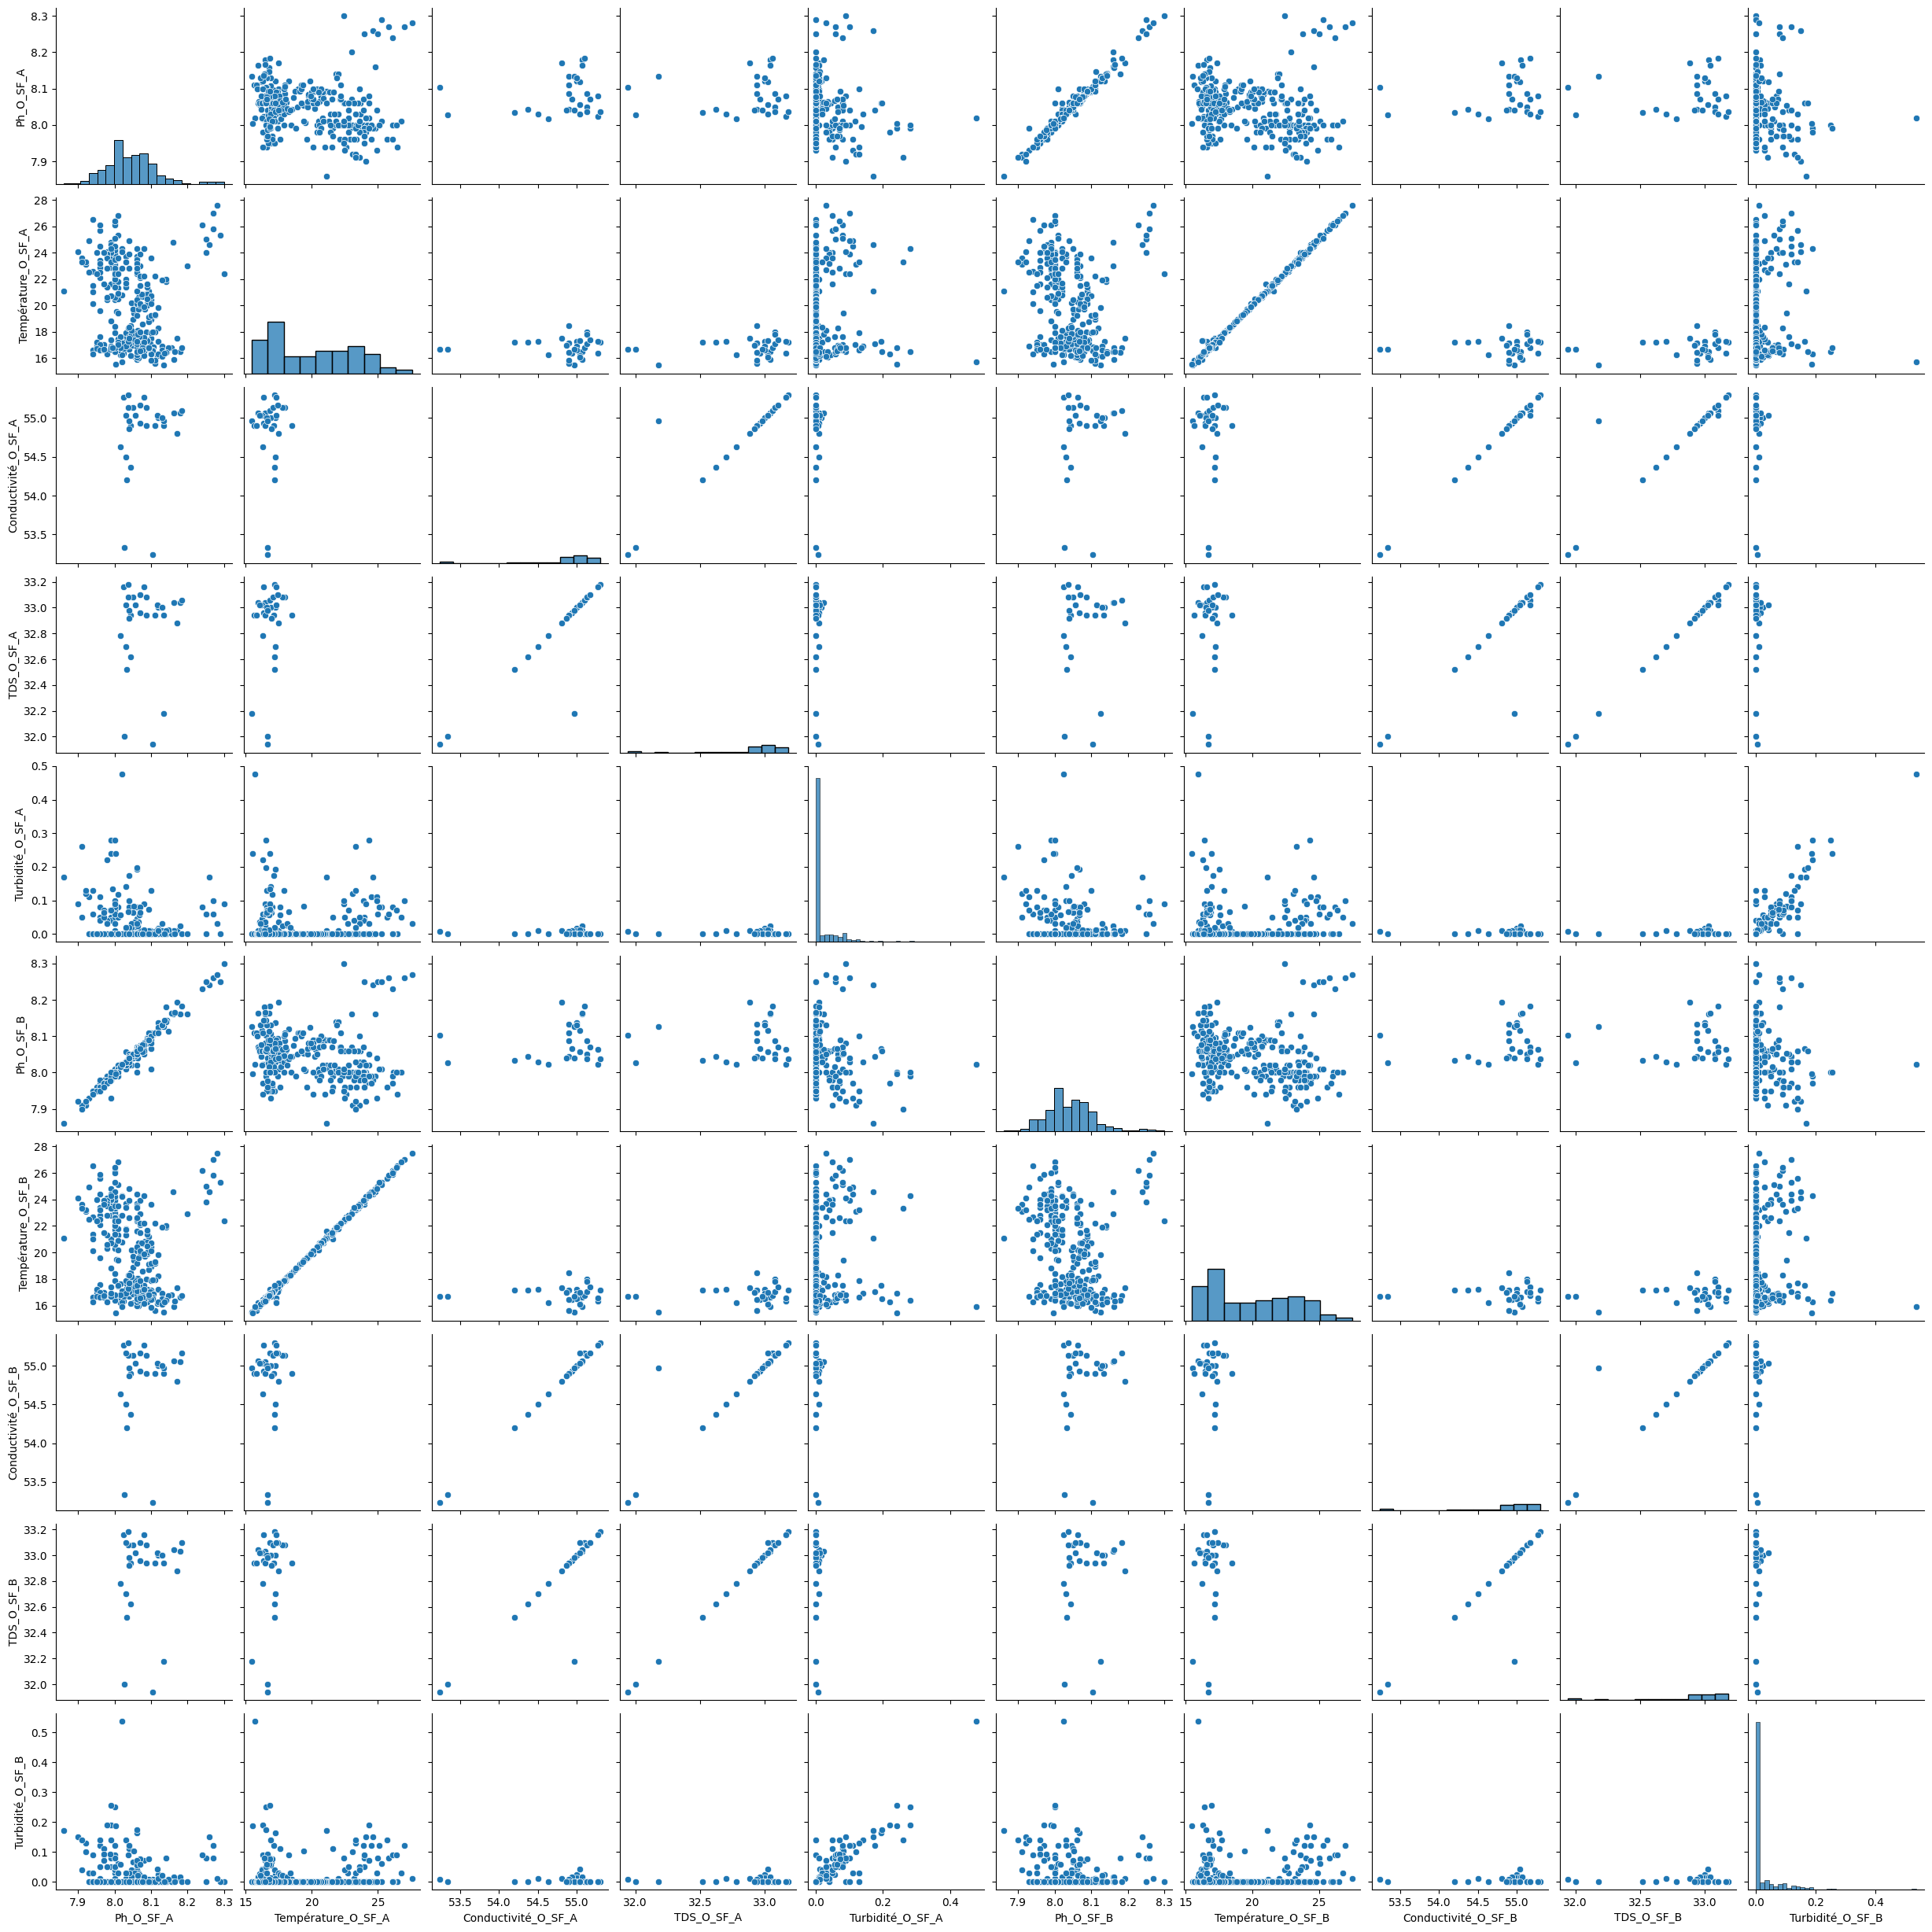

In [9]:
sns.pairplot(SF_data.iloc[:, 1:])

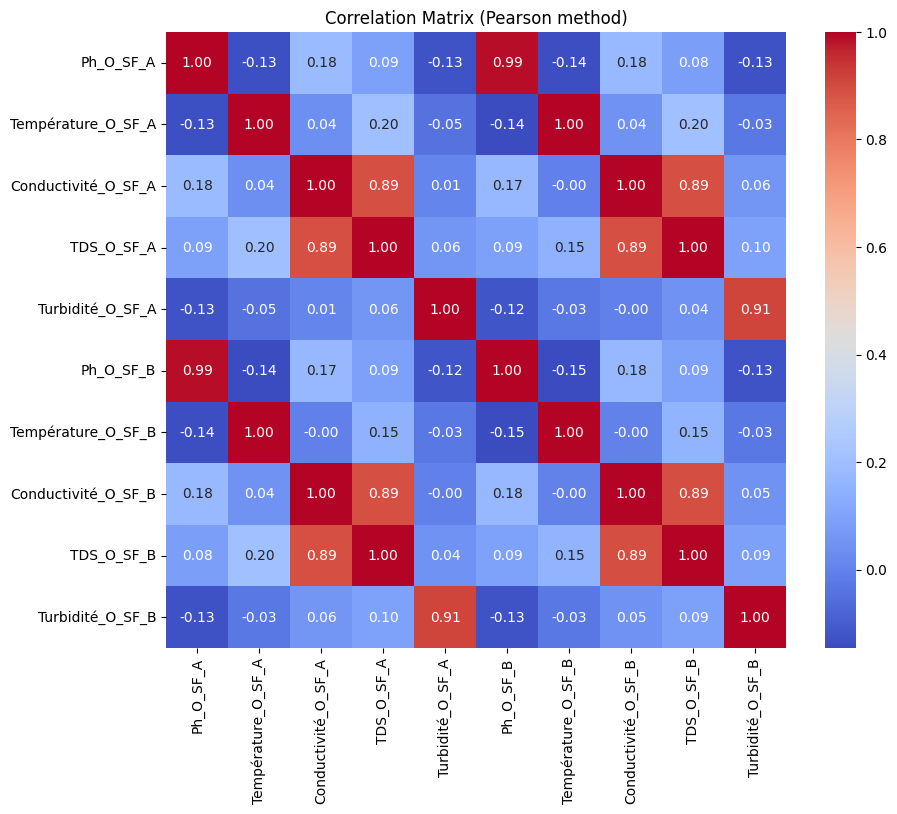

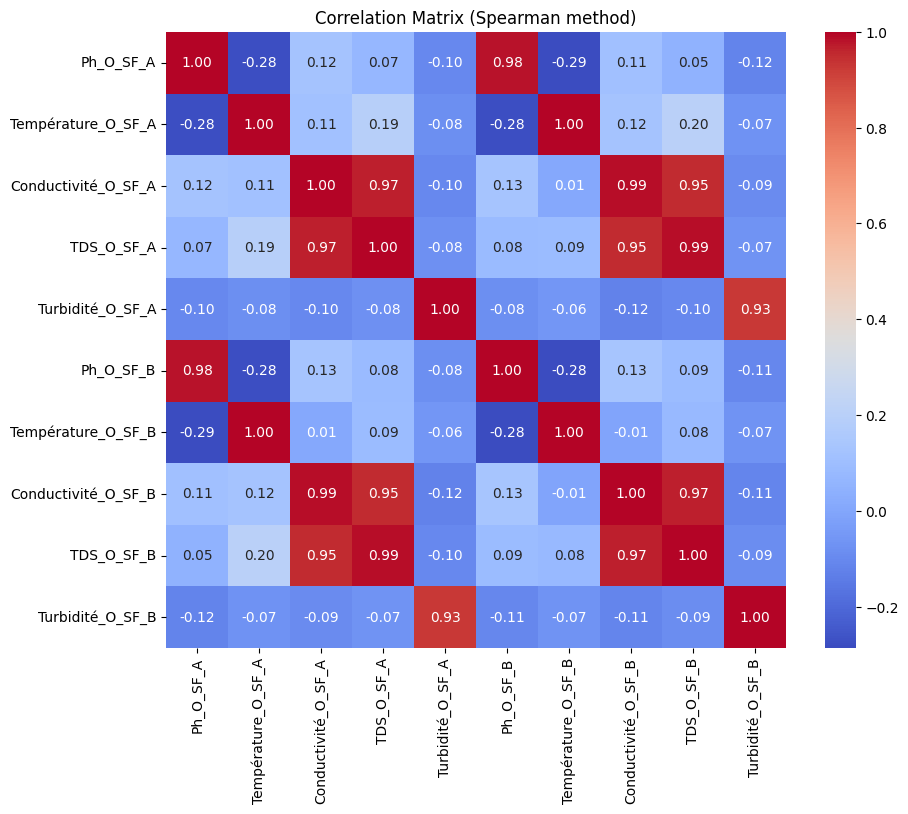

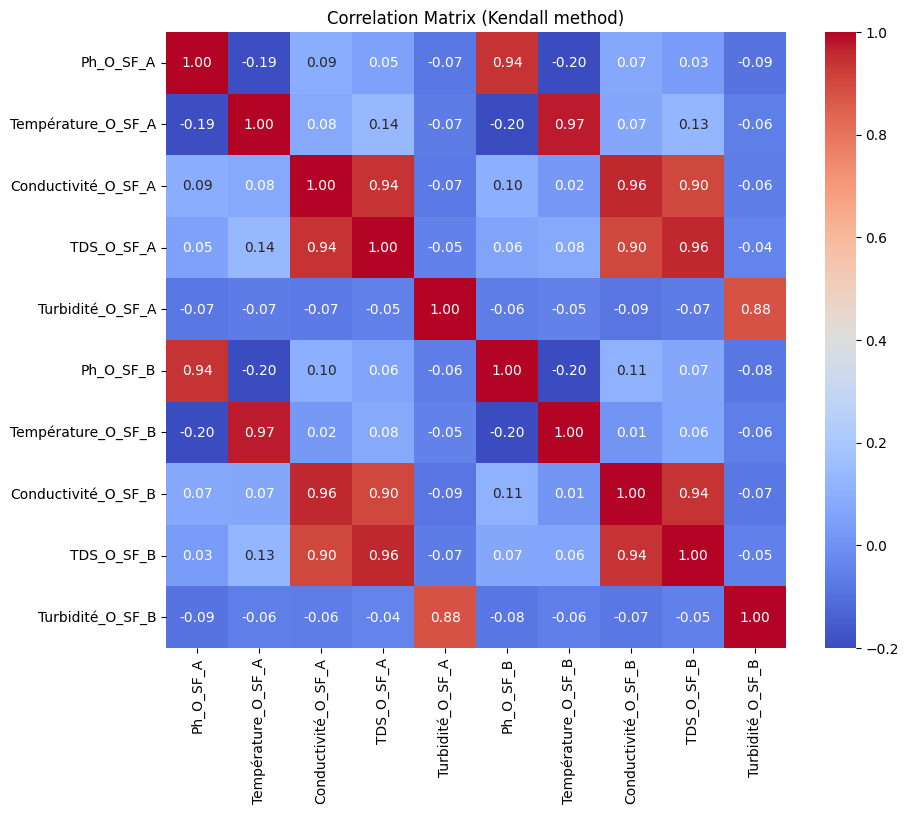

In [10]:
# calculate the correlation matrix using Pearson correlation, spearman correlation, and Kendall correlation
correlation_methods = ['pearson', 'spearman', 'kendall']
for method in correlation_methods:
    corr_matrix = SF_data.iloc[:, 1:].corr(method=method)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title(f'Correlation Matrix ({method.capitalize()} method)')
    plt.show()

#### Time series features analysis

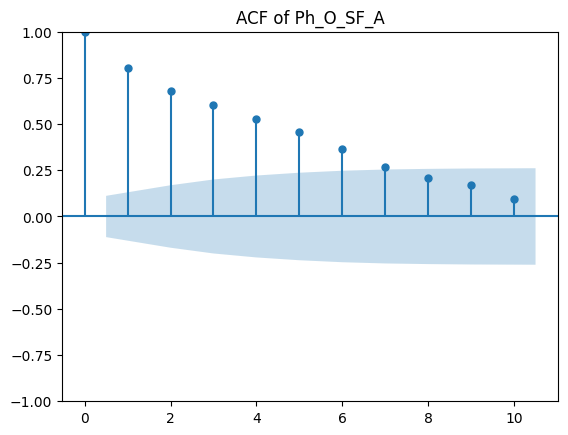

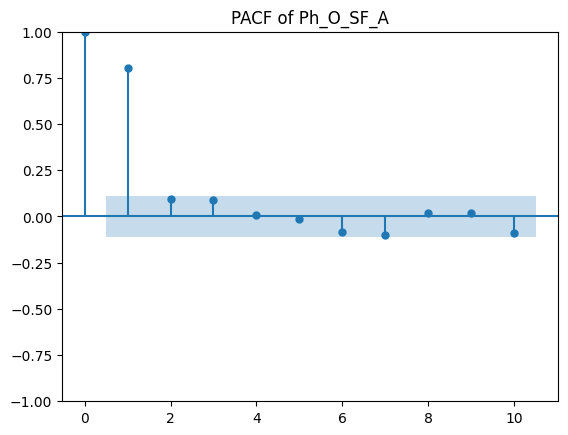

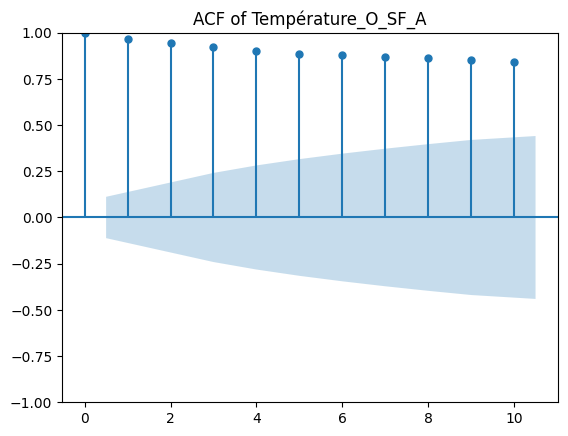

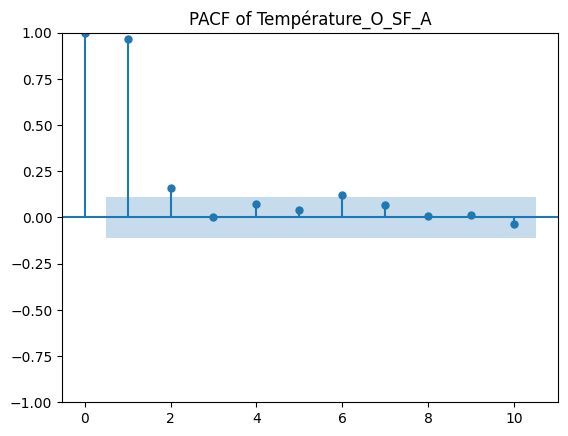

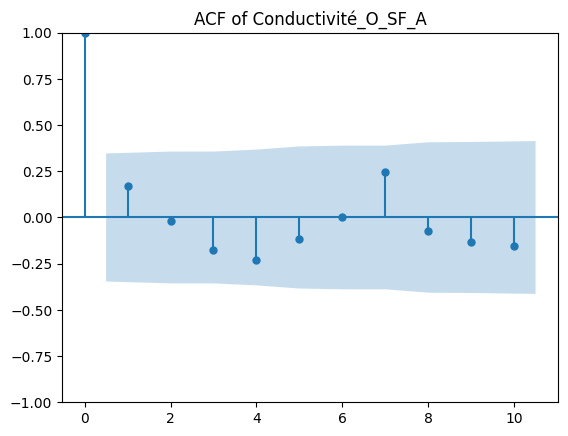

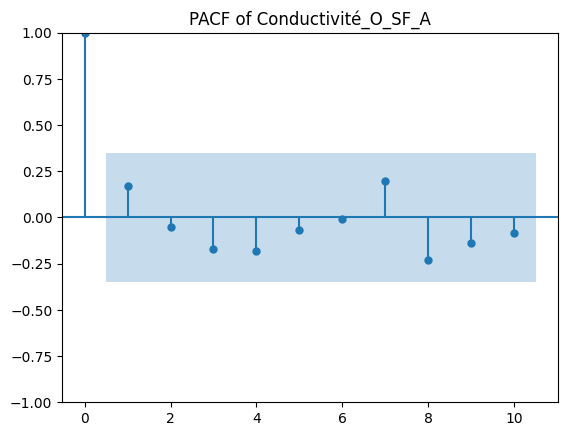

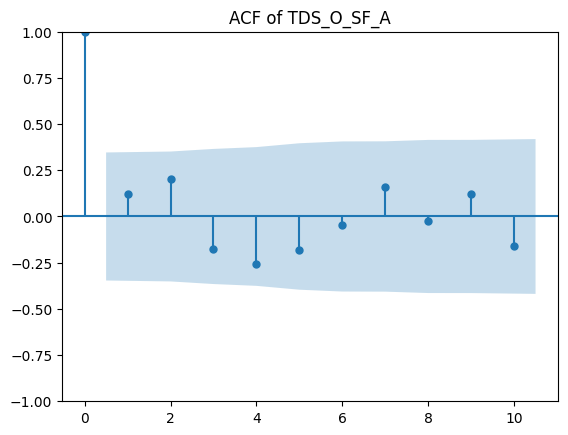

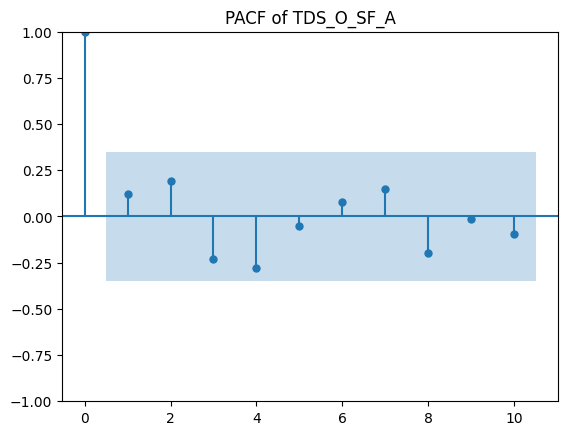

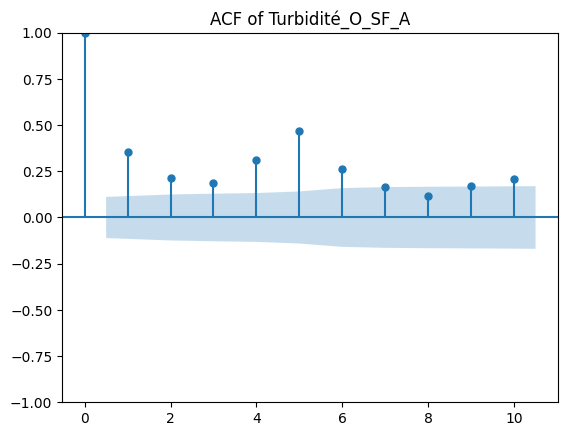

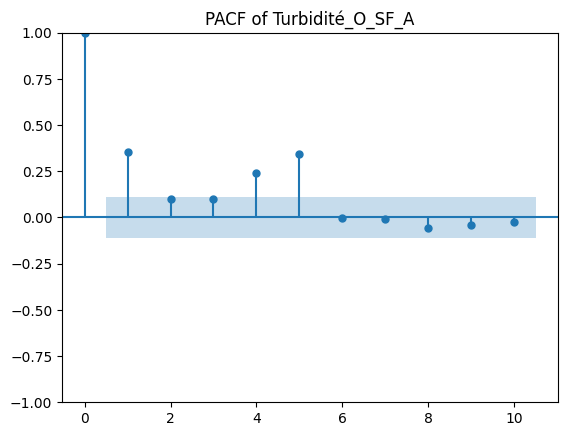

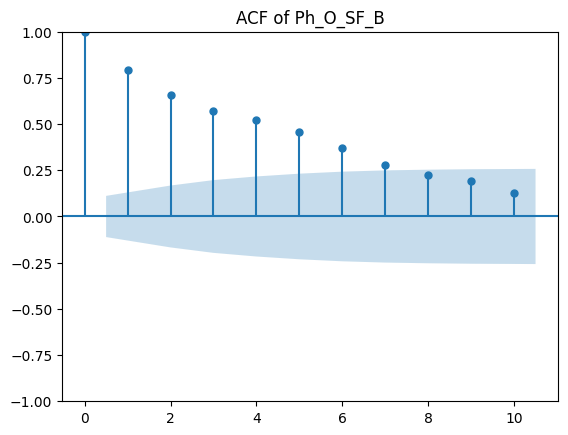

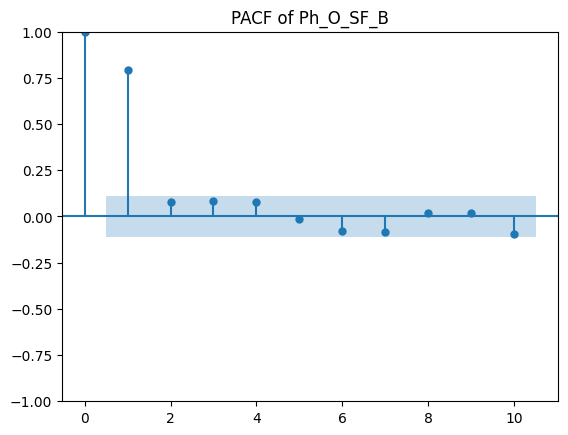

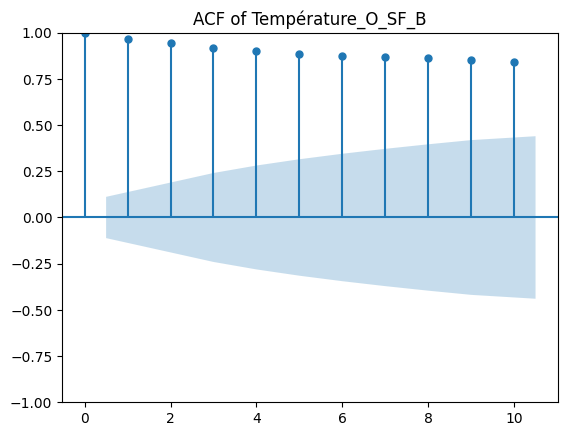

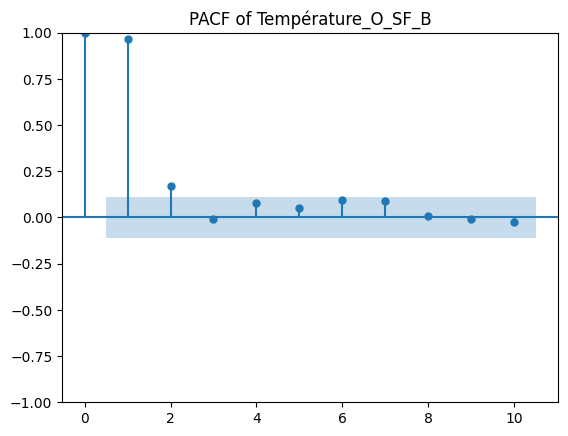

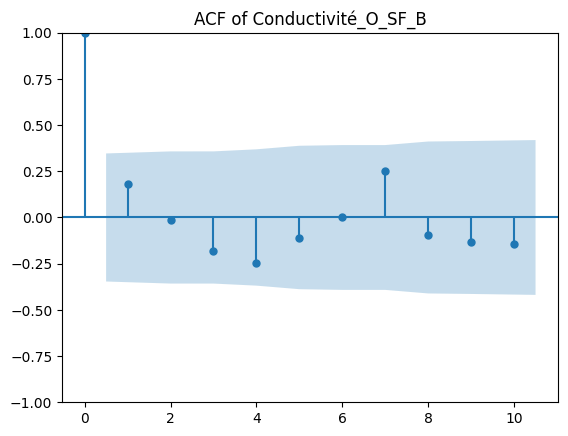

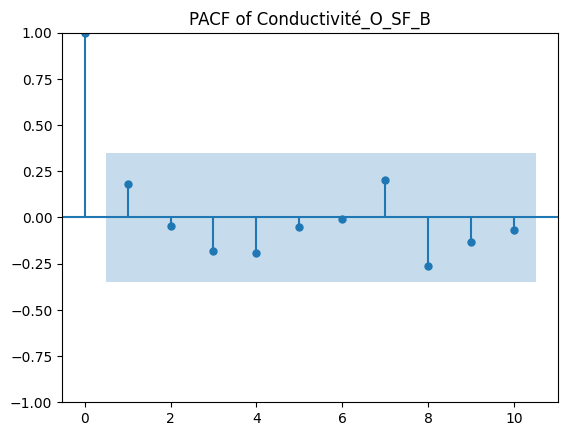

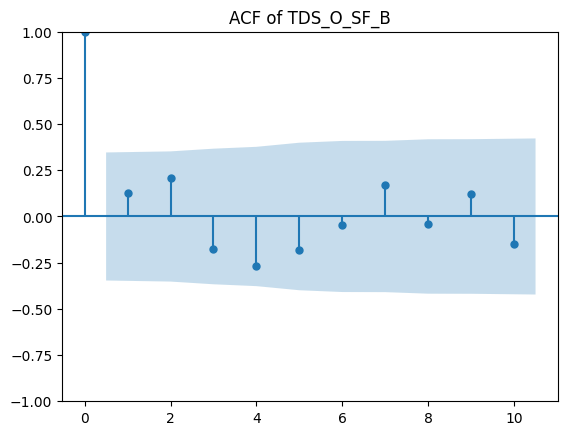

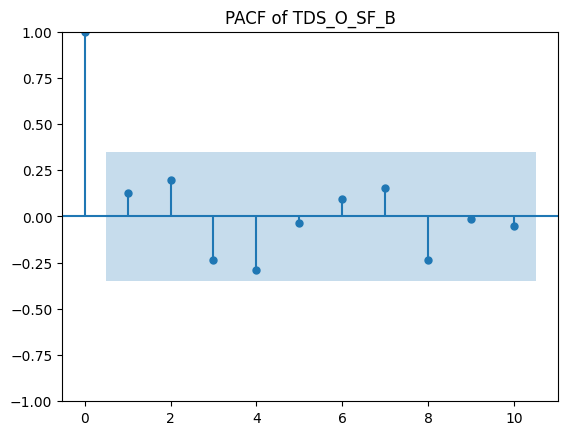

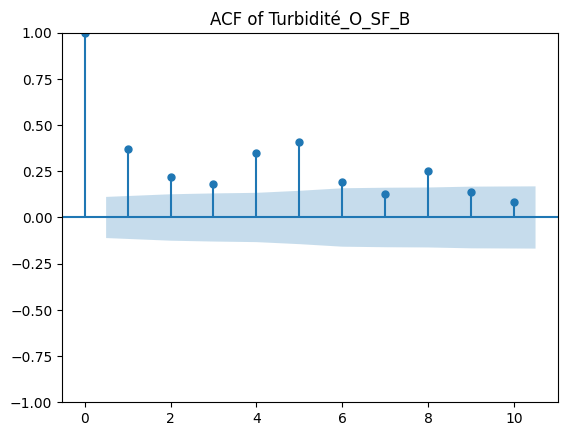

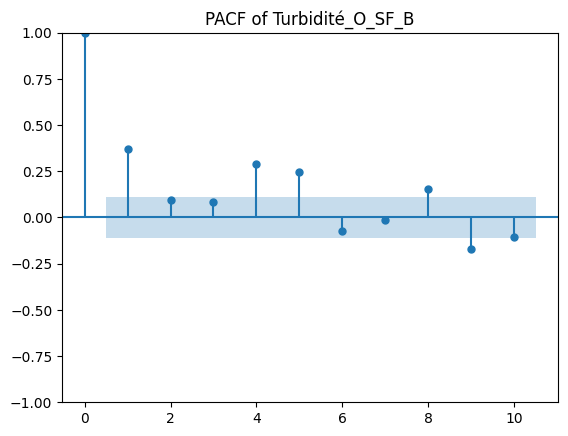

In [11]:
# ACF and PACF for each BC variable
for col in SF_data.columns[1:]:
    plot_acf(SF_data[col].dropna(), lags=10)
    plt.title(f'ACF of {col}')
    plt.show()

    plot_pacf(SF_data[col].dropna(), lags=10)
    plt.title(f'PACF of {col}')
    plt.show()

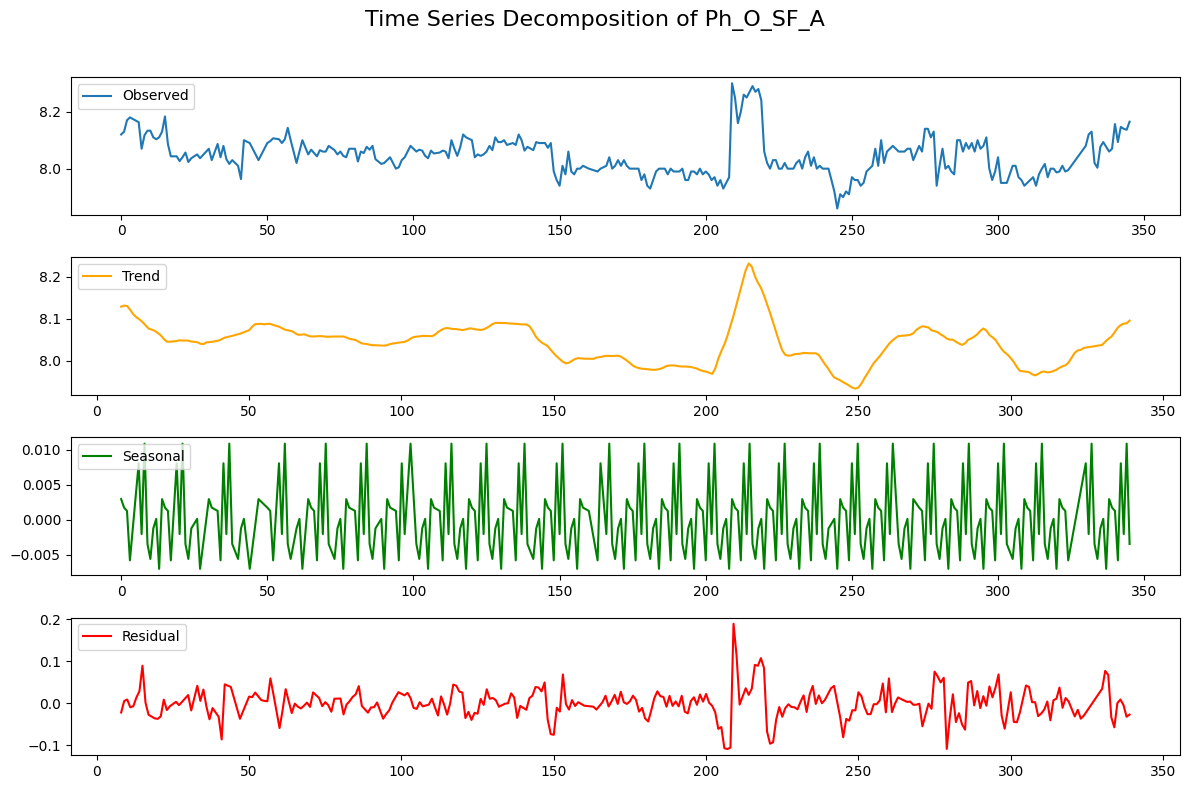

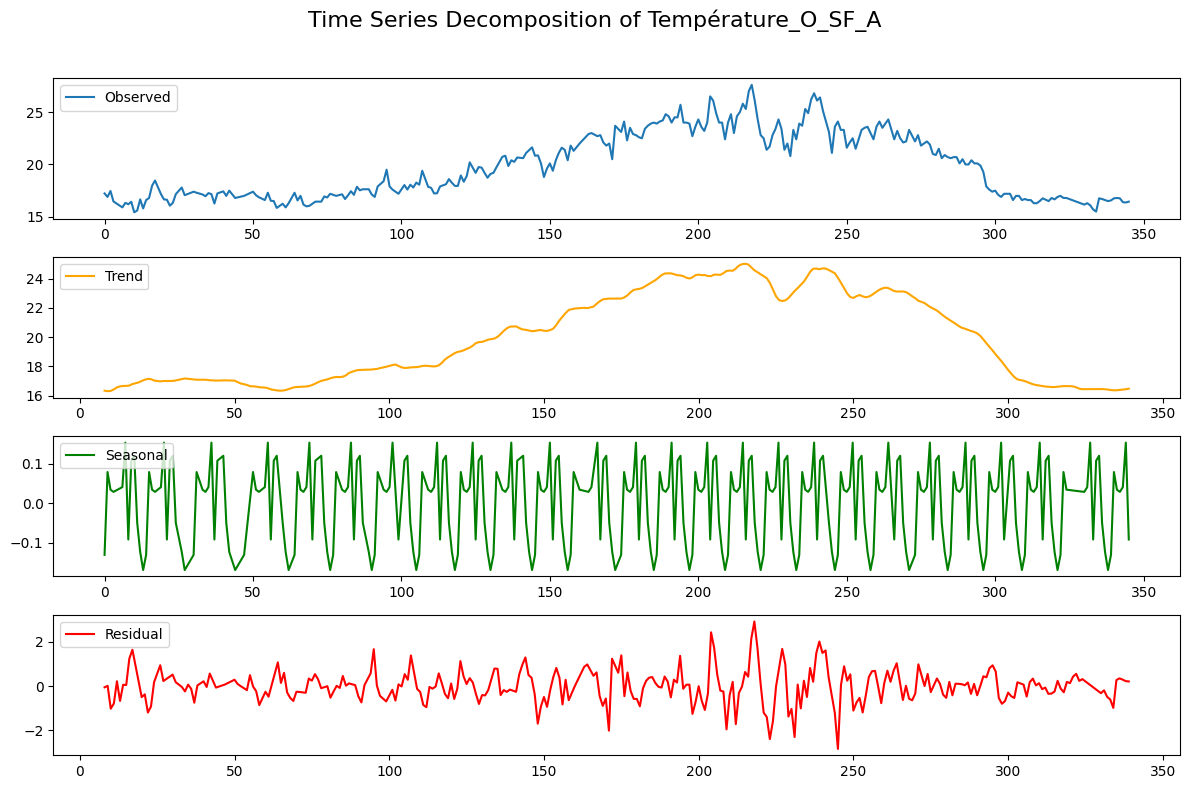

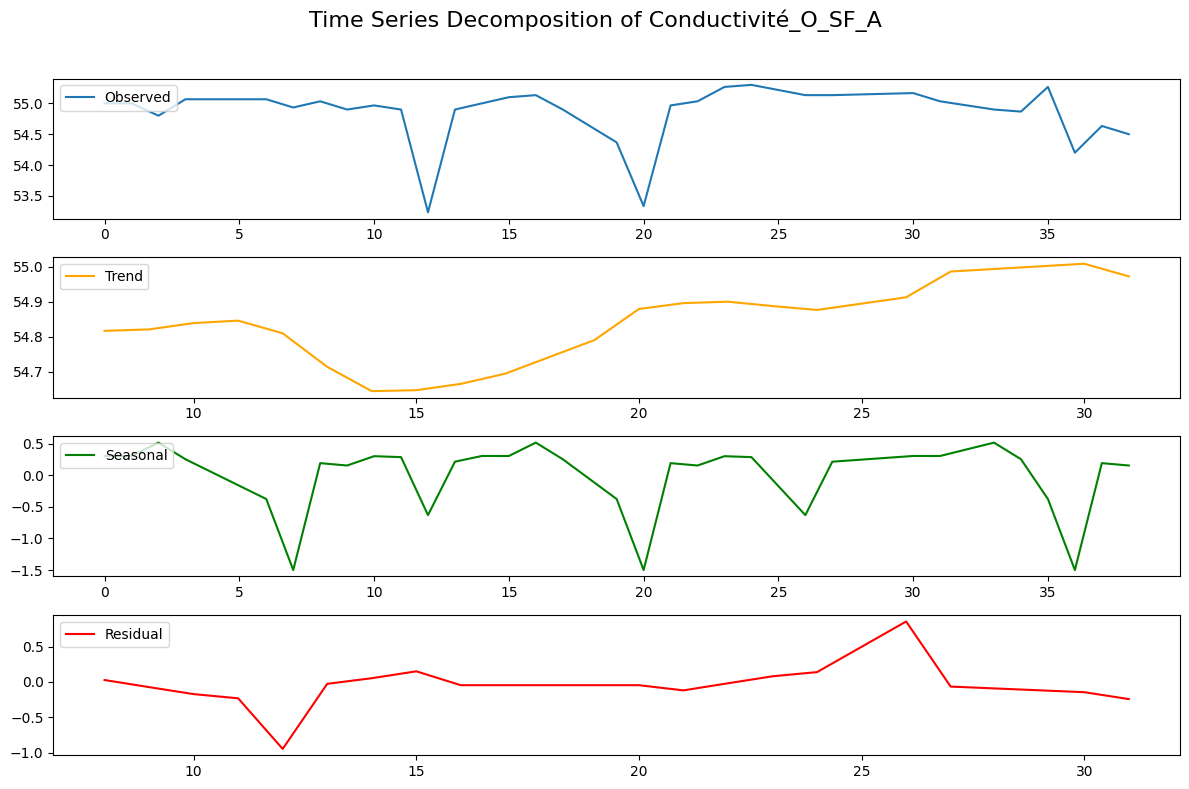

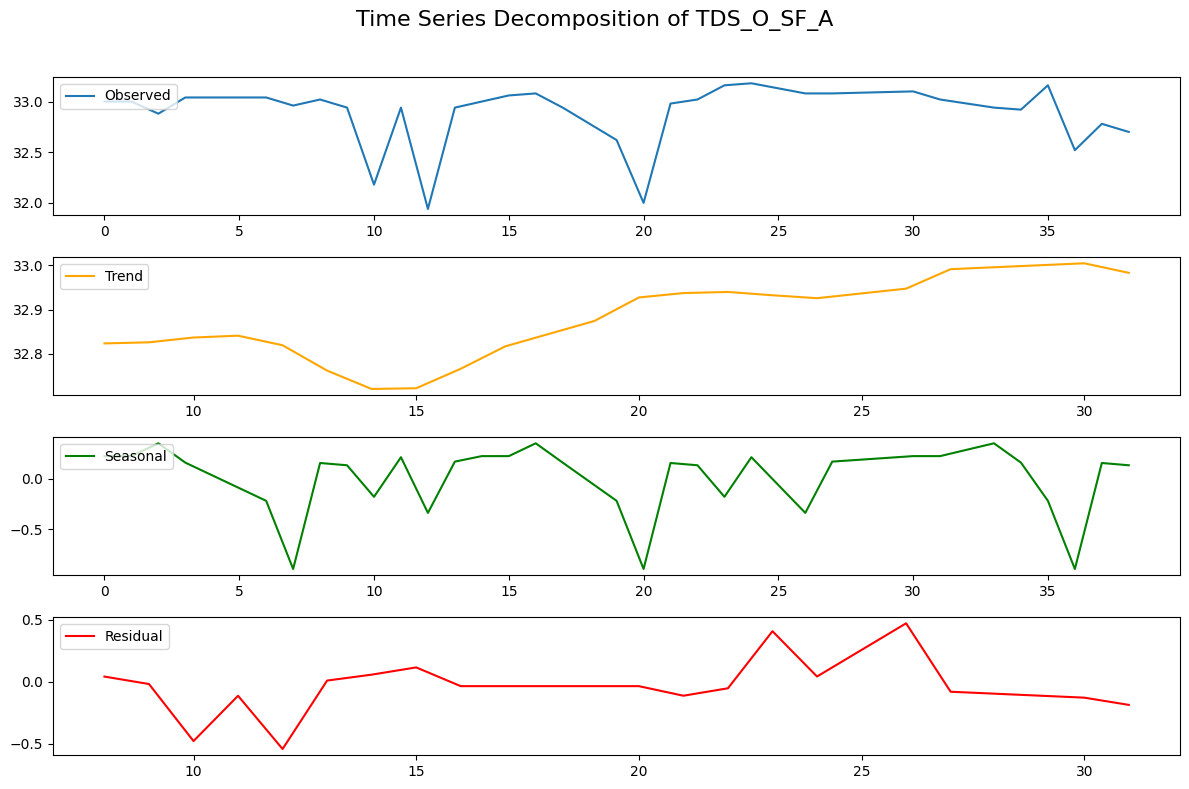

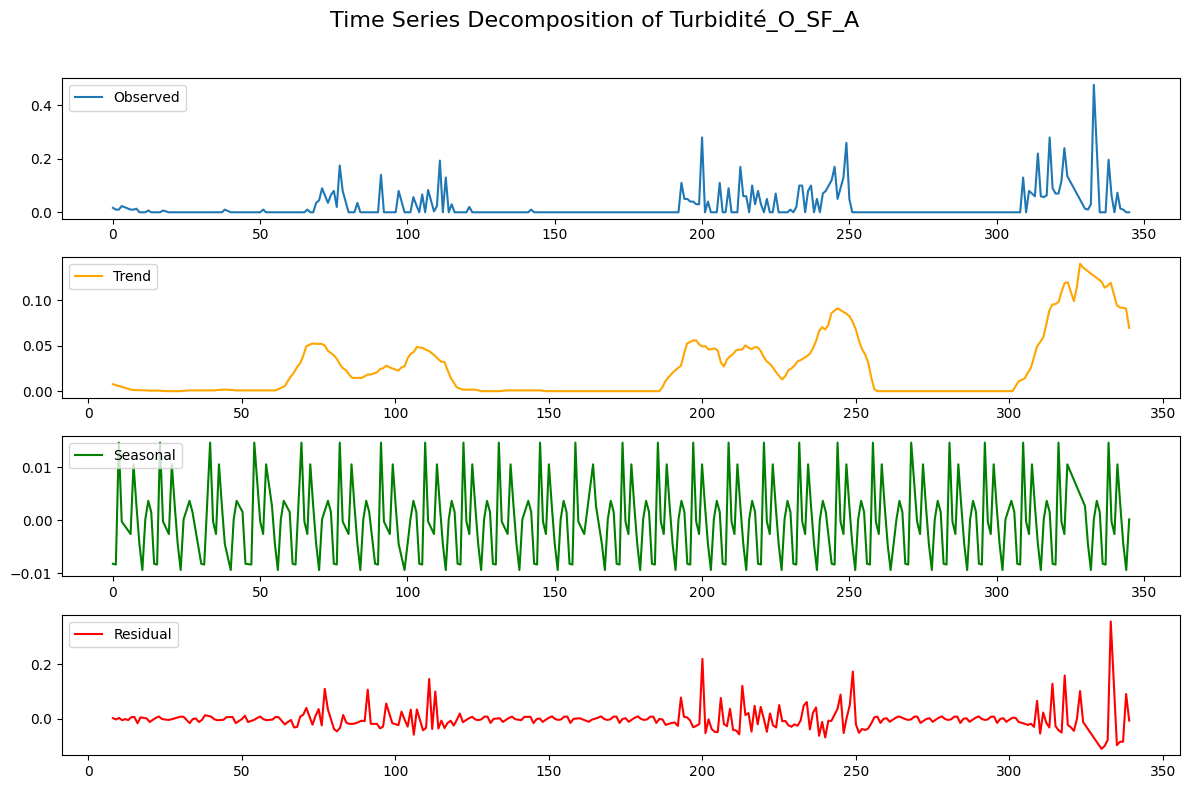

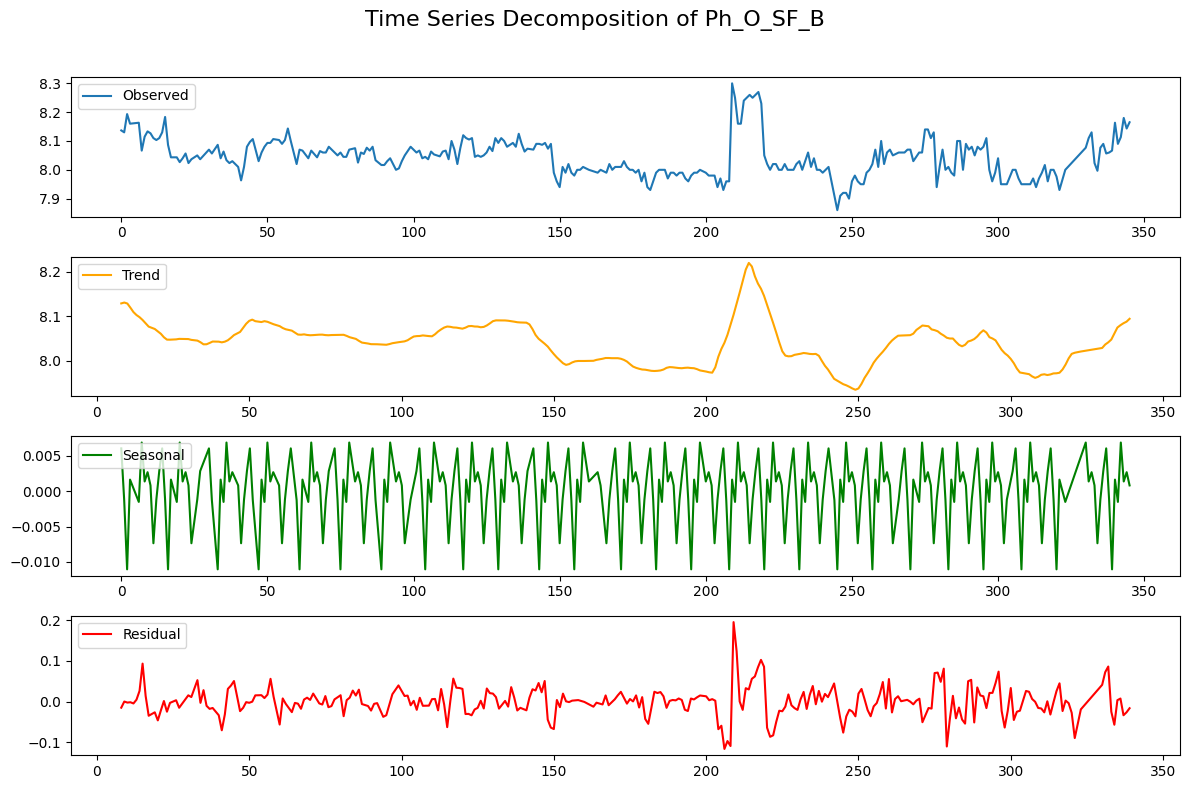

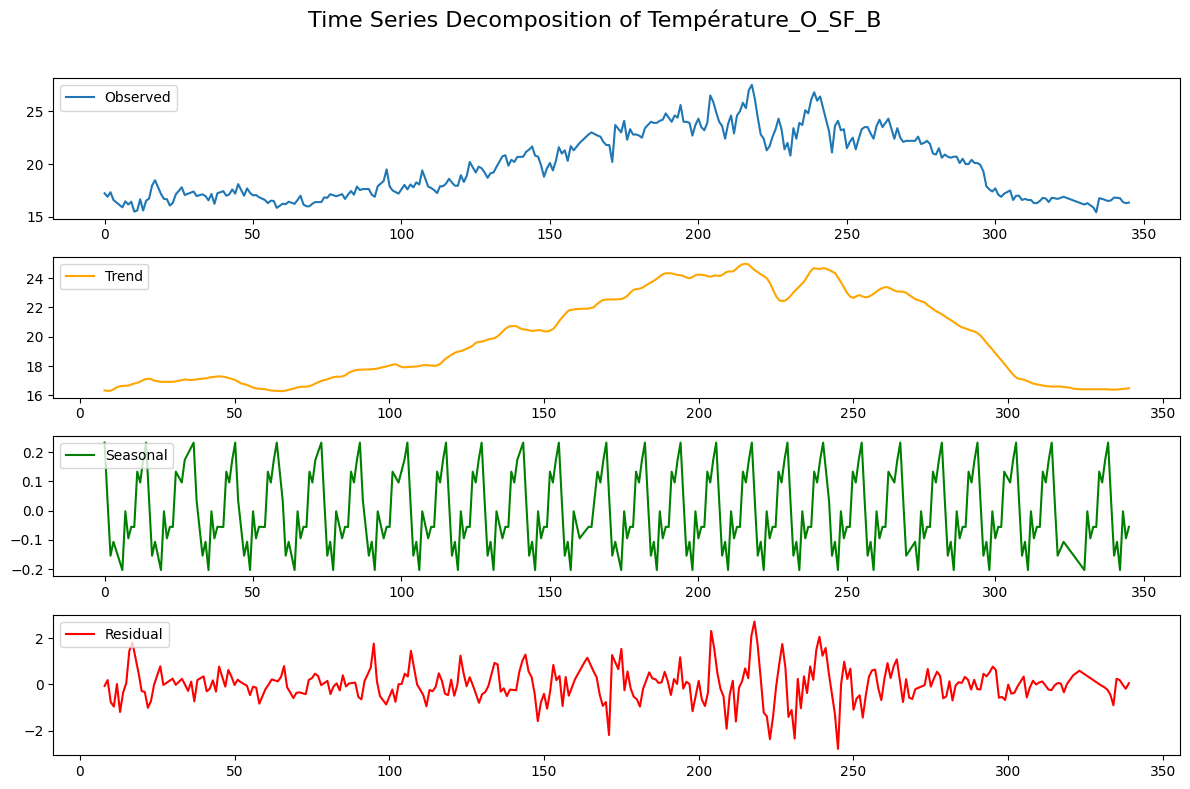

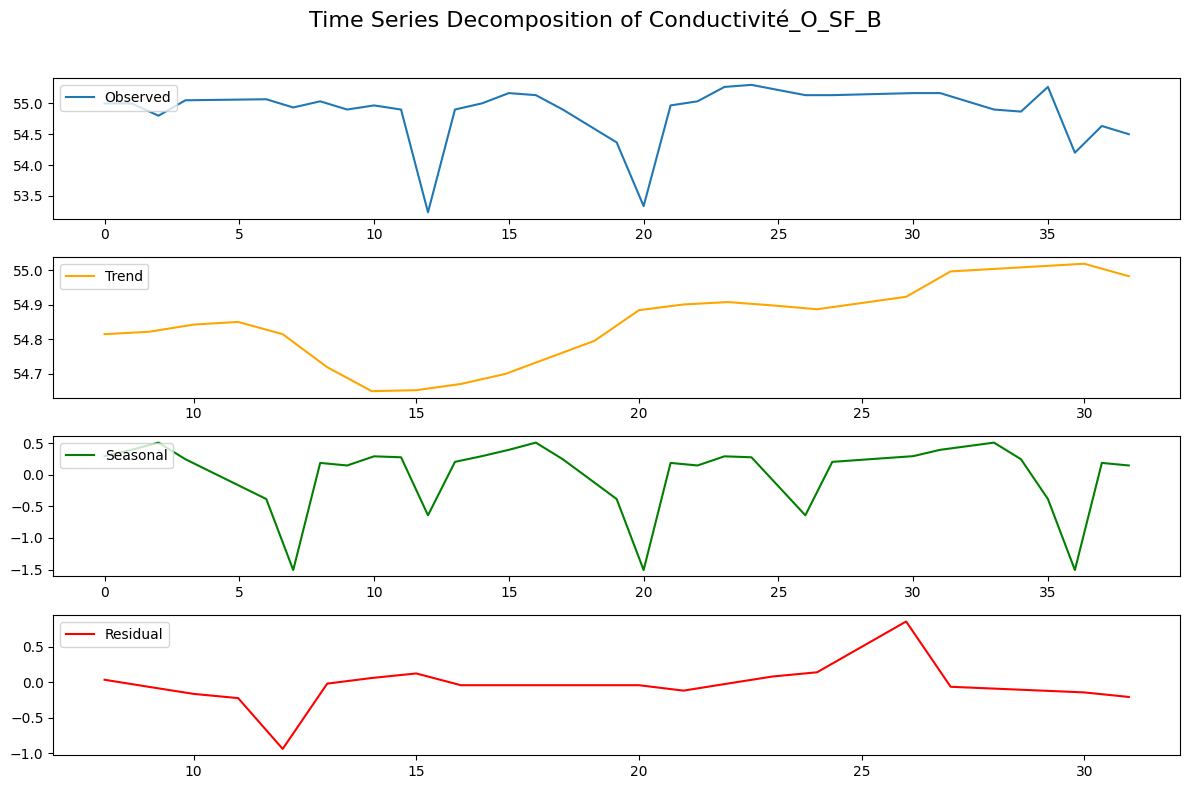

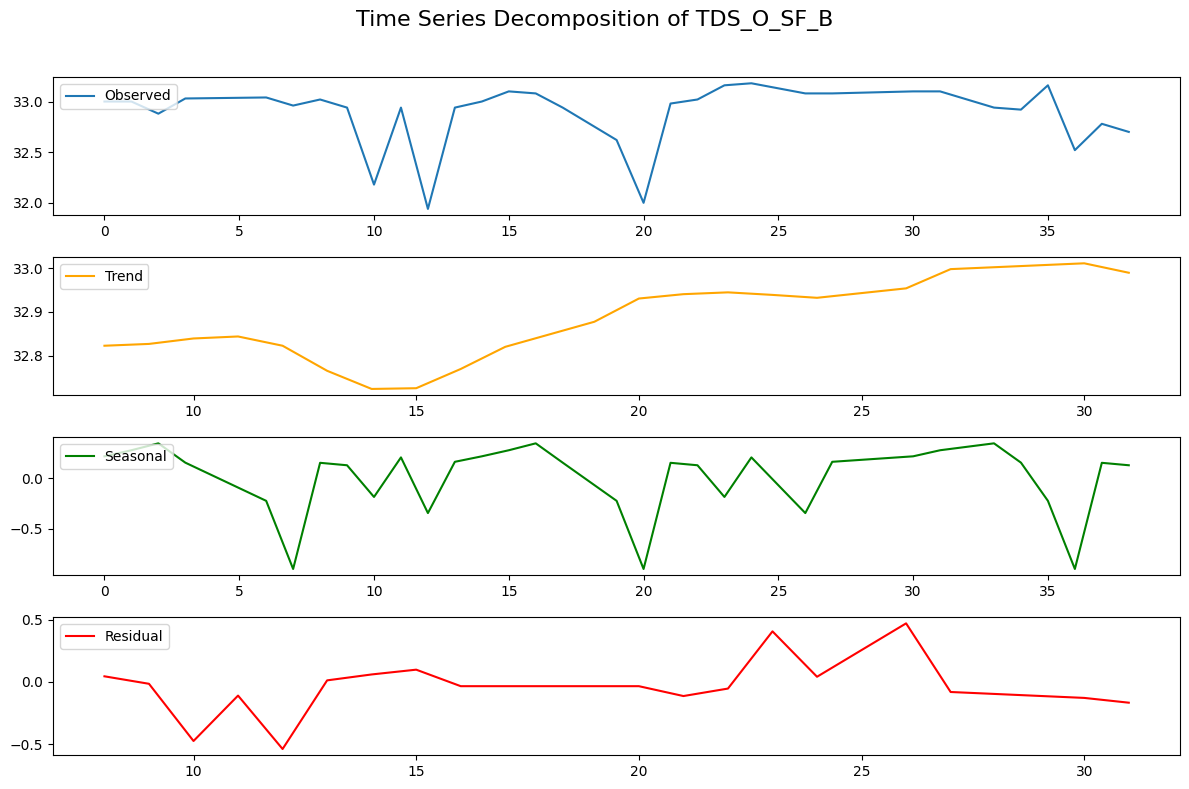

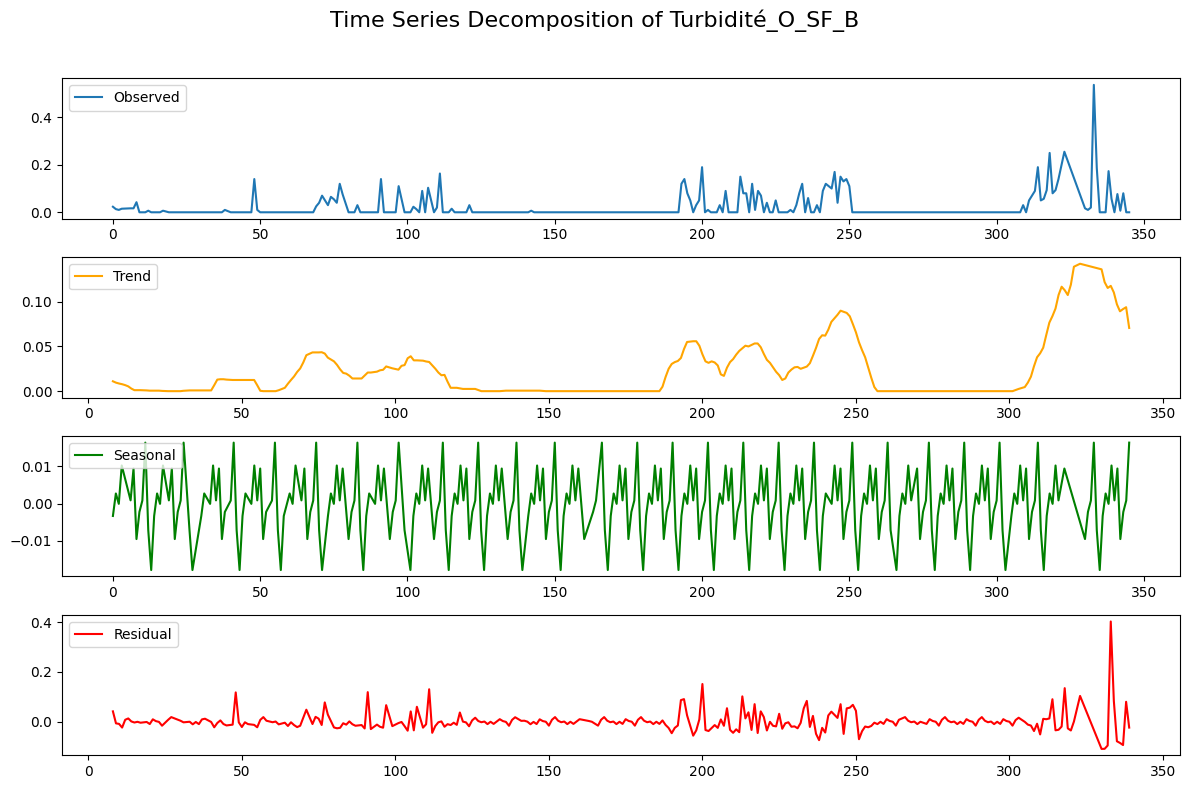

In [12]:
# time series decomposition for each SF variable

for col in SF_data.columns[1:]:
    decomp = seasonal_decompose(SF_data[col].dropna(), model='additive', period=12)
    plt.figure(figsize=(12, 8))
    plt.suptitle(f'Time Series Decomposition of {col}', fontsize=16)
    plt.subplot(411)
    plt.plot(decomp.observed, label='Observed')
    plt.legend(loc='upper left')
    plt.subplot(412)
    plt.plot(decomp.trend, label='Trend', color='orange')
    plt.legend(loc='upper left')
    plt.subplot(413)
    plt.plot(decomp.seasonal, label='Seasonal', color='green')
    plt.legend(loc='upper left')
    plt.subplot(414)
    plt.plot(decomp.resid, label='Residual', color='red')
    plt.legend(loc='upper left')
    plt.tight_layout(rect=[0, 0, 1, 0.96])